In [1]:
import pandas as pd

df = pd.read_csv('ending_club_preprocessed2.csv', parse_dates=['issue_d', 'earliest_cr_line'])


C:\Users\gywns\AppData\Local\Temp\ipykernel_10588\2004928192.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv('ending_club_preprocessed2.csv', parse_dates=['issue_d', 'earliest_cr_line'])


In [2]:
import numpy as np
import pandas as pd
from scipy.stats import shapiro, levene

def is_categorical(series, unique_threshold=10):
    s = series.dropna()
    if (
        pd.api.types.is_object_dtype(s)
        or isinstance(s.dtype, pd.CategoricalDtype)
        or pd.api.types.is_bool_dtype(s)
    ):
        return True
    if pd.api.types.is_integer_dtype(s) and s.nunique() <= unique_threshold:
        return True
    return False

def check_variable_type_normality_homoscedasticity(
    df: pd.DataFrame,
    target_col: str,
    feature_col: str,
    alpha: float = 0.05
):
    y = df[target_col]
    x = df[feature_col]

    if set(y.dropna().unique()) - {0, 1}:
        raise ValueError(f"{target_col}은 0/1 이진형이어야 합니다.")

    result = {
        "feature": feature_col,
        "feature_type": None,
        "normality_p_y0": np.nan,
        "normality_p_y1": np.nan,
        "normality_ok": None,
        "levene_p": np.nan,
        "equal_variance_ok": None,
        "note": ""
    }

    if is_categorical(x):
        result["feature_type"] = "categorical"
        result["note"] = "범주형 변수는 정규성/등분산성 검정을 하지 않습니다."
        return result

    result["feature_type"] = "continuous"
    g0 = x[y == 0].dropna()
    g1 = x[y == 1].dropna()

    if len(g0) < 3 or len(g1) < 3:
        result["note"] = "각 그룹 표본이 3개 미만이라 정규성/등분산성 검정이 어렵습니다."
        return result

    p0 = shapiro(g0.iloc[:5000]).pvalue
    p1 = shapiro(g1.iloc[:5000]).pvalue
    result["normality_p_y0"] = p0
    result["normality_p_y1"] = p1
    result["normality_ok"] = (p0 >= alpha) and (p1 >= alpha)

    lp = levene(g0, g1).pvalue
    result["levene_p"] = lp
    result["equal_variance_ok"] = (lp >= alpha)

    return result


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def plot_normality_by_target(df, target_col, feature_col, bins=30):
    g0 = df.loc[df[target_col] == 0, feature_col].dropna()
    g1 = df.loc[df[target_col] == 1, feature_col].dropna()

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"{feature_col} | Normality Check by {target_col}", fontsize=14)

    # y=0 히스토그램
    sns.histplot(g0, bins=bins, kde=True, ax=axes[0, 0], color="#4C72B0")
    axes[0, 0].set_title(f"Histogram (y=0), n={len(g0)}")

    # y=0 QQ plot
    stats.probplot(g0, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title("QQ Plot (y=0)")

    # y=1 히스토그램
    sns.histplot(g1, bins=bins, kde=True, ax=axes[1, 0], color="#DD8452")
    axes[1, 0].set_title(f"Histogram (y=1), n={len(g1)}")

    # y=1 QQ plot
    stats.probplot(g1, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title("QQ Plot (y=1)")

    plt.tight_layout()
    plt.show()


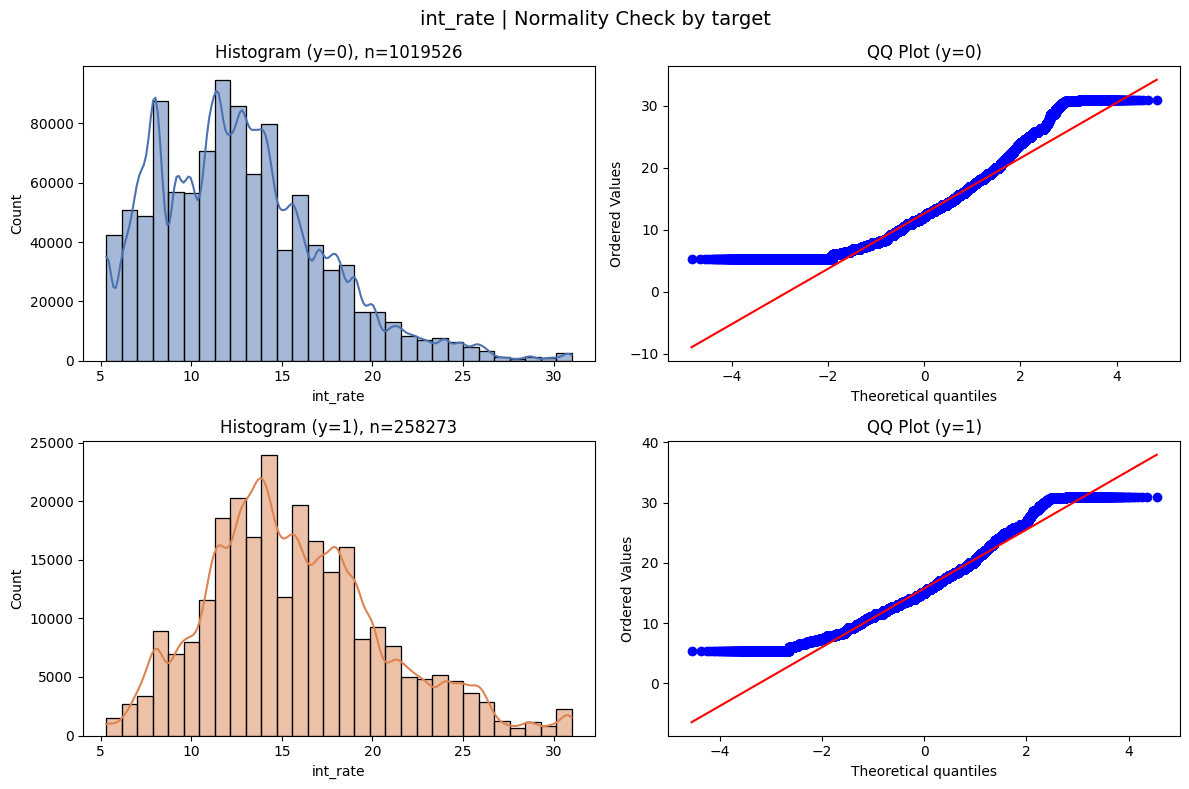

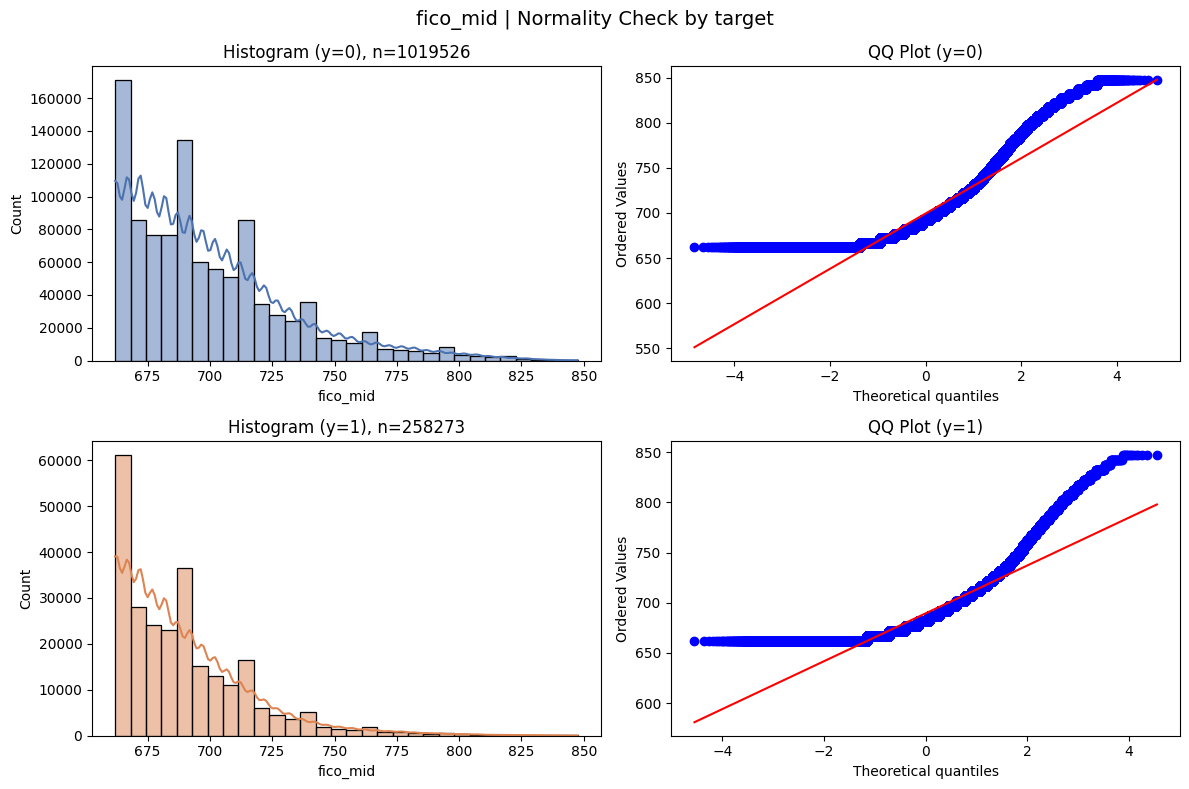

In [ ]:
target = "target"
features = ["int_rate", "fico_mid"]


for f in features:
    plot_normality_by_target(df, target, f, bins=30)


In [8]:
analysis_results = []

for col in features:
    res = check_variable_type_normality_homoscedasticity(df, 'target', col)
    analysis_results.append(res)

# 결과를 데이터프레임으로 변환해서 예쁘게 보기
result_df = pd.DataFrame(analysis_results)
display(result_df)

,feature,feature_type,normality_p_y0,normality_p_y1,normality_ok,levene_p,equal_variance_ok,note
0,int_rate,continuous,5.072951e-36,7.181871e-27,False,0.0,False,
1,fico_mid,continuous,1.678073e-49,2.695899e-55,False,0.0,False,


In [9]:
# 검정할 피처 지정
lst = ['term', 'issue_year', 'sub_grade']

# 교차표 만들기
term_ct = pd.crosstab(df['term'], df['target'])
issue_year_ct = pd.crosstab(df['issue_year'], df['target'])
sub_grade_ct = pd.crosstab(df['sub_grade'], df['target'])

display(term_ct)
display(issue_year_ct)
display(sub_grade_ct)


target,0.0,1.0
term,,
36 months,812242,156859
60 months,207284,101414


target,0.0,1.0
issue_year,,
2012,21630,3995
2013,113775,21023
2014,181938,41159
2015,299741,75804
2016,224853,68252
2017,130148,39168
2018,47441,8872


target,0.0,1.0
sub_grade,,
A1,40170,1337
A2,32992,1602
A3,33201,1899
A4,44190,3247
A5,54788,5020
B1,60868,7075
B2,62406,7979
B3,66202,9931
B4,67104,11718


In [25]:
# 카이제곱 검정

def CramerV(df, col1, col2):
    temp = df.copy()
    ct_test= pd.crosstab(temp[col1], temp[col2])
    chi2, p_value, dof, expected = stats.chi2_contingency(ct_test)
    n = ct_test.sum().sum()
    r, c = ct_test.shape
    df_star = min(r - 1, c - 1)
    cramers_v = np.sqrt(chi2 / (n * df_star))
    return [cramers_v, chi2, p_value, dof, expected]


# , 'issue_year', 'sub_grade'
lst = ['issue_year', 'term']
for col in lst:
    print(f'{col}의 통계량, 효과크기 검정')
    #print("기대빈도:\n", expected)
    print(f"카이제곱 통계량: {CramerV(df, col, 'target')[1]:.2f}, ")
    print(f"자유도:         {CramerV(df, col, 'target')[3]}, ")
    print(f"p-value:        {CramerV(df, col, 'target')[2]:.4f}, " )
    print(f"Cramér's V:     {CramerV(df, col, 'target')[0]}, ")
    print(f"기대빈도: {CramerV(df, col, 'target')[4]}, ")
    print('\n','='*50,'\n')

issue_year의 통계량, 효과크기 검정
카이제곱 통계량: 5857.47, 
자유도:         6, 
p-value:        0.0000, 
Cramér's V:     0.06770544898119066, 
기대빈도: [[ 20445.58944717   5179.41055283]
 [107552.17819704  27245.82180296]
 [178003.88951783  45093.11048217]
 [299638.59078775  75906.40921225]
 [233861.63882582  59243.36117418]
 [135093.28479362  34222.71520638]
 [ 44930.82843076  11382.17156924]], 


term의 통계량, 효과크기 검정
카이제곱 통계량: 40322.46, 
자유도:         1, 
p-value:        0.0000, 
Cramér's V:     0.17764060553682764, 
기대빈도: [[773223.0703937 195877.9296063]
 [246302.9296063  62395.0703937]], 




In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import platform

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

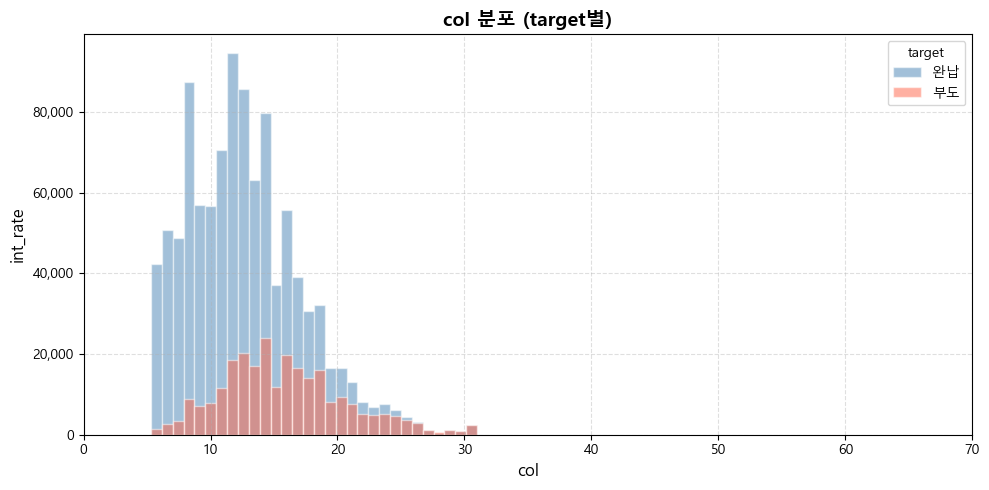

In [15]:
# 타켓 별 히스토그램 탐색 
colors = {0: "steelblue", 1: "tomato"}
labels = {0: "완납", 1: "부도"}

fig, ax = plt.subplots(figsize=(10, 5))

for group, data in df.groupby("target")["int_rate"]:
    data.dropna().plot(
        kind="hist",
        alpha=0.5,
        bins=30,
        color=colors[group],
        label=labels[group],
        edgecolor="white",
        ax=ax
    )

ax.set_title("col 분포 (target별)", fontsize=14, fontweight="bold")
ax.set_xlabel("col", fontsize=12)
ax.set_ylabel("int_rate", fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(title="target")
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_xlim(0, 70)  
plt.tight_layout()
plt.show()

In [19]:
df['int_rate'].describe()

count    1.277799e+06
mean     1.327806e+01
std      4.800893e+00
min      5.310000e+00
25%      9.750000e+00
50%      1.274000e+01
75%      1.602000e+01
max      3.099000e+01
Name: int_rate, dtype: float64

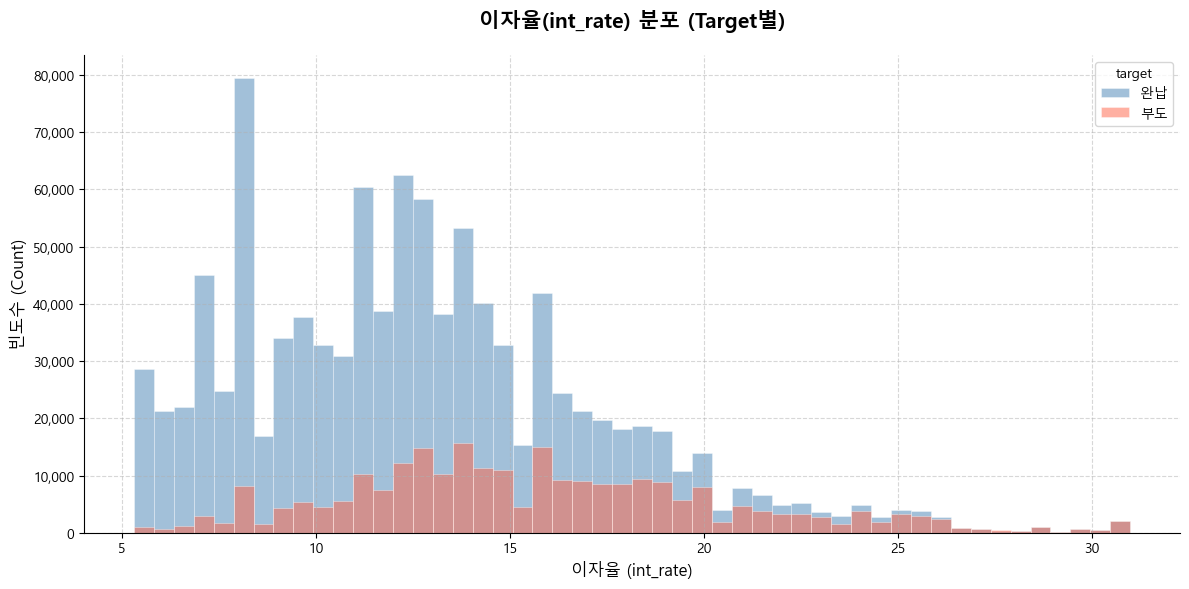

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# 데이터 로드 (이미 불러오셨다면 이 줄은 생략하세요)
# df = pd.read_csv('ending_club_preprocessed2.csv', parse_dates=['issue_d', 'earliest_cr_line'])

# 1. 설정값 준비
colors = {0: "steelblue", 1: "tomato"}
labels = {0: "완납", 1: "부도"}

# 2. 도화지 그리기
fig, ax = plt.subplots(figsize=(12, 6))

# 3. 타겟별로 반복하여 히스토그램 생성
for group, data in df.groupby("target")["int_rate"]:
    data.dropna().plot(
        kind="hist",
        alpha=0.5,           # 막대 투명도 (이미지처럼 겹쳐 보이게 함)
        bins=50,             # 막대 개수 (이미지의 세밀함에 따라 조정 가능)
        color=colors[group],
        label=labels[group],
        edgecolor="white",   # 막대 사이 흰색 테두리
        linewidth=0.5,
        ax=ax
    )

# 4. 스타일 디테일 수정
ax.set_title("이자율(int_rate) 분포 (Target별)", fontsize=15, fontweight="bold", pad=20)
ax.set_xlabel("이자율 (int_rate)", fontsize=12)
ax.set_ylabel("빈도수 (Count)", fontsize=12)

# y축 천 단위 콤마 포맷 (데이터가 많을 경우 유용)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# 범례 설정
ax.legend(title="target", loc="upper right", frameon=True)

# 배경 격자 (이미지와 유사한 점선 스타일)
ax.grid(True, linestyle="--", alpha=0.5)

# 불필요한 테두리 제거 (선택 사항)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

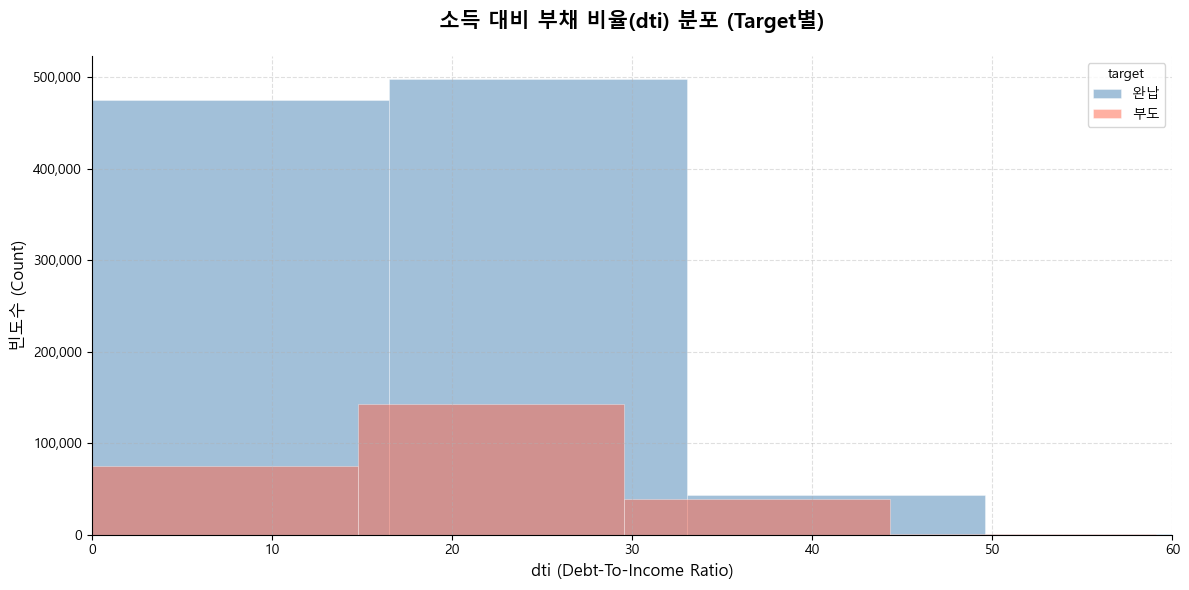

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. 설정값 준비 (색상과 라벨은 이전과 동일하게 유지)
colors = {0: "steelblue", 1: "tomato"}
labels = {0: "완납", 1: "부도"}

# 2. 도화지 생성
fig, ax = plt.subplots(figsize=(12, 6))

# 3. target별로 반복하며 dti 히스토그램 생성
for group, data in df.groupby("target")["dti"]:
    data.dropna().plot(
        kind="hist",
        alpha=0.5,           # 겹쳐 보이는 효과
        bins=60,             # dti는 범위가 넓으므로 조금 더 세밀하게 설정
        color=colors[group],
        label=labels[group],
        edgecolor="white",   # 막대 구분선
        linewidth=0.5,
        ax=ax
    )

# 4. 그래프 꾸미기 (타이틀 및 라벨 변경)
ax.set_title("소득 대비 부채 비율(dti) 분포 (Target별)", fontsize=15, fontweight="bold", pad=20)
ax.set_xlabel("dti (Debt-To-Income Ratio)", fontsize=12)
ax.set_ylabel("빈도수 (Count)", fontsize=12)

# y축 천 단위 콤마 포맷
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# dti의 일반적인 범위를 고려하여 x축 제한 (필요시 조정 가능)
# 보통 dti가 100 이상인 이상치가 있을 수 있어 0~60 정도로 제한하면 분포가 잘 보입니다.
ax.set_xlim(0, 60) 

# 범례 및 격자 설정
ax.legend(title="target", loc="upper right")
ax.grid(True, linestyle="--", alpha=0.4)

# 테두리 정리
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

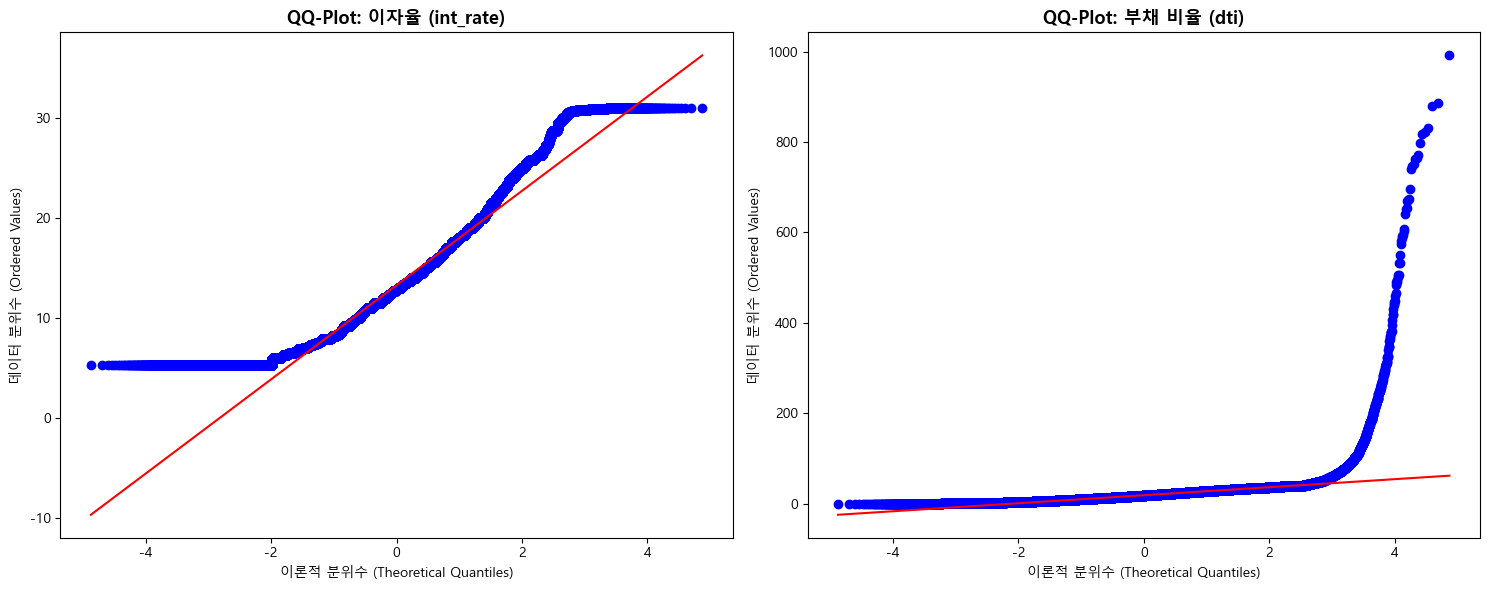

In [22]:
# 1. 시각화 영역 설정 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 2. int_rate QQ-Plot
# stats.probplot은 데이터를 정규분포와 비교하여 산점도를 그려줍니다.
stats.probplot(df['int_rate'].dropna(), dist="norm", plot=axes[0])
axes[0].set_title("QQ-Plot: 이자율 (int_rate)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("이론적 분위수 (Theoretical Quantiles)")
axes[0].set_ylabel("데이터 분위수 (Ordered Values)")

# 3. dti QQ-Plot
stats.probplot(df['dti'].dropna(), dist="norm", plot=axes[1])
axes[1].set_title("QQ-Plot: 부채 비율 (dti)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("이론적 분위수 (Theoretical Quantiles)")
axes[1].set_ylabel("데이터 분위수 (Ordered Values)")

# 그래프 간격 조정 및 출력
plt.tight_layout()
plt.show()

C:\Users\gywns\AppData\Local\Temp\ipykernel_10588\3051442358.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('dti_qqplot.png', dpi=300, bbox_inches='tight', transparent=False)


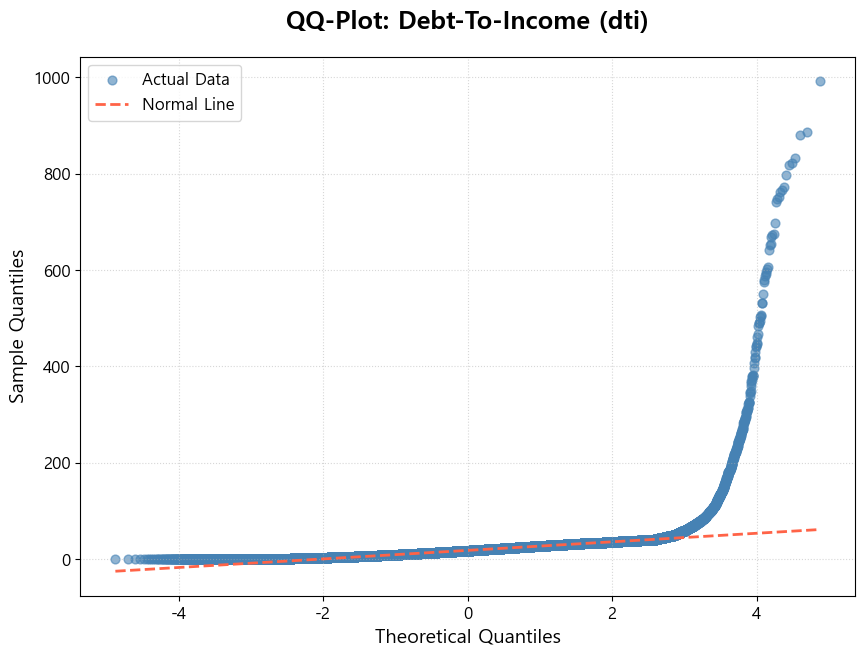

In [26]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. 스타일 및 폰트 설정 (PPT 가독성용)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 2. 도화지 크기 설정 (PPT 한 슬라이드에 적합한 비율)
plt.figure(figsize=(10, 7))

# 3. QQ-Plot 그리기
# 시각적 개선을 위해 점의 색상과 선의 스타일을 살짝 조정합니다.
(osm, osr), (slope, intercept, r) = stats.probplot(df['dti'].dropna(), dist="norm", plot=None)

# 실제 데이터 점 (투명도를 주어 밀집도 확인 가능하게)
plt.scatter(osm, osr, color='steelblue', alpha=0.6, label='Actual Data', s=40)
# 이론적 직선
plt.plot(osm, slope*osm + intercept, color='tomato', linestyle='--', linewidth=2, label='Normal Line')

# 4. 제목 및 라벨 (크기를 키워 PPT 뒷자리에서도 보이게)
plt.title("QQ-Plot: Debt-To-Income (dti)", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Theoretical Quantiles", fontsize=14)
plt.ylabel("Sample Quantiles", fontsize=14)

# 5. 격자 및 디자인 디테일
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()

# 6. 핵심: 고해상도 저장 (이 코드가 PPT 화질을 결정합니다)
# dpi=300: 인쇄물 수준의 고화질
# bbox_inches='tight': 불필요한 흰색 여백 제거
plt.savefig('dti_qqplot.png', dpi=300, bbox_inches='tight', transparent=False)

plt.show()

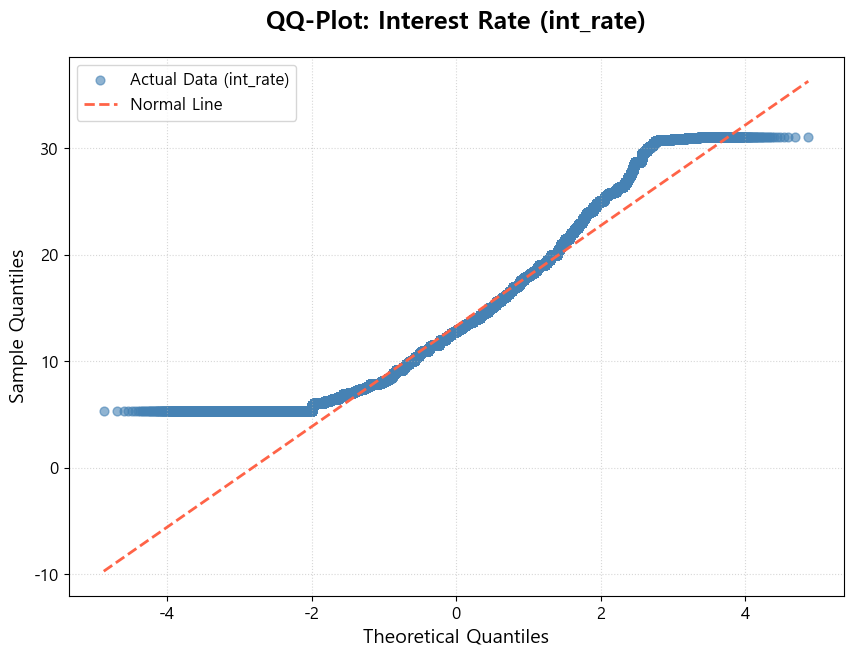

In [27]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. 스타일 및 폰트 설정
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False 

# 2. 도화지 크기 설정
plt.figure(figsize=(10, 7))

# 3. QQ-Plot 데이터 계산 및 그리기
# int_rate 변수를 사용하여 계산합니다.
(osm, osr), (slope, intercept, r) = stats.probplot(df['int_rate'].dropna(), dist="norm", plot=None)

# 실제 데이터 점 (steelblue 색상으로 깔끔하게)
plt.scatter(osm, osr, color='steelblue', alpha=0.6, label='Actual Data (int_rate)', s=40)
# 이론적 직선 (tomato 색상 점선)
plt.plot(osm, slope*osm + intercept, color='tomato', linestyle='--', linewidth=2, label='Normal Line')

# 4. 제목 및 라벨 (영문/국문 중 선호하시는 것으로 선택하세요)
plt.title("QQ-Plot: Interest Rate (int_rate)", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Theoretical Quantiles", fontsize=14)
plt.ylabel("Sample Quantiles", fontsize=14)

# 5. 격자 및 디자인 디테일
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()

# 6. 고해상도 저장
# 파일명을 변수명과 일치시켜 저장하면 관리가 편합니다.
plt.savefig('int_rate_qqplot.png', dpi=300, bbox_inches='tight')

plt.show()